# Divergence Comparison for Adversarially-Robust Classification (TRADES-style)

This notebook is a from-scratch, **runnable-on-Colab** experiment that compares five
statistical divergences as the robustness regularizer inside a **TRADES-style** loss:

$$\mathcal{L}(x,y) \;=\; \mathcal{CE}\big(f(x), y\big) \;+\; \beta \cdot \mathcal{D}\Big(f(x_{\text{adv}}) \,\big\|\, f(x)\Big)$$

where $\mathcal{D}$ is one of **KL**, **Rényi** ($\alpha$-parameterized), **Tsallis**
($\alpha$-parameterized), **Jensen–Shannon**, or **Hellinger**, and $x_{\text{adv}}$ is found by
maximizing $\mathcal{D}$ (the "TPGD"/"TFGSM" inner maximization from TRADES).

### Fixed hyperparameters (no sweeping in this version)

This is a **fixed-hyperparameter** version of the original comparison notebook. Instead of
re-running an $\alpha$-sweep and $\beta$-sweep at experiment time, it plugs in the **best
values those sweeps already found** — taken directly from the executed outputs of the
original notebook — and spends the full compute budget on the main 3-dataset × 5-divergence
comparison instead:

| Hyperparameter | Value used | Where it came from |
|---|---|---|
| Rényi $\alpha$ | **3.0** | $\alpha$-sweep on CIFAR-10 (PGD-AT): best PGD-20 accuracy (23.3%) among {0.3, 0.5, 0.8, 1.5, 2.0, 3.0, 5.0} |
| Tsallis $\alpha$ | **2.0** | $\alpha$-sweep on CIFAR-10 (PGD-AT): best PGD-20 accuracy (22.0%) among the same grid |
| TRADES $\beta$ | **10.0** | $\beta$-sweep on CIFAR-10 (KL, PGD-AT): best PGD-20 accuracy (20.3%) within 5pp of the best clean accuracy, among {0.5, 1.0, 3.0, 6.0, 10.0} |

These replace the old defaults ($\alpha{=}1.5$ for both, $\beta{=}6.0$) everywhere in the main
sweep, training routines, and evaluation below. **No alpha/beta sweep is executed in this
notebook** — the old $\alpha$-sweep and $\beta$-sweep sections have been removed entirely,
since their job (finding the best value) is already done; what's left is spending the saved
compute on the cleanest possible Rényi-vs-KL-vs-Tsallis-vs-JS-vs-Hellinger comparison at
those tuned values, across all three datasets and both FGSM-AT/PGD-AT training modes.

### Relationship to the base paper (arXiv:2410.07675, *"Adversarial Robustness
Overestimation and Instability in TRADES"*)

That paper does **not** compare divergences — it uses **vanilla TRADES with KL only**
(Eq. 1) and studies a different question: under which hyperparameters (small $\beta$,
small batch size, large LR, high class-count) does TRADES exhibit **robustness
overestimation** — i.e. PGD-10 validation accuracy looks great but **AutoAttack**
(APGD-CE + APGD-DLR + FAB + **Square Attack**) accuracy is far lower, revealing
**gradient masking**. It diagnoses this with FOSC / SGCS metrics, loss-landscape
plots, and proposes a Gaussian-noise "self-healing" fix (Algorithm 1).

This notebook borrows the paper's **evaluation methodology** (multi-attack tables,
PGD-vs-black-box gap as a gradient-masking signal) and applies it **across 5
divergences and 3 datasets**, which is the extension you described. What is *not*
reimplemented from the paper (flagged again at the very end, with reasons):
FOSC/SGCS trajectories, loss-landscape surface plots, Adversarial Weight
Perturbation, and the Algorithm-1 self-healing training loop. These are a second,
separate project (state-tracking through training, not just before/after eval) — say
the word and they can be added as a follow-up notebook. The $\alpha$/$\beta$-sweep
sections were never part of the base paper either — they were this project's own
tuning step, and that tuning is now folded into the fixed values above rather than
re-run live.

### What this notebook does
| Section | Content |
|---|---|
| 1–4 | Setup, config, **3 datasets** (small MNIST, small CIFAR-10, small "Mini-ImageNet"/Imagenette-64), adaptive CNN |
| 5 | The 5 divergence functions, Rényi/Tsallis bound to their **tuned** $\alpha$ values (3.0 / 2.0) |
| 6 | Attack generators (TFGSM / TPGD, divergence-aware) used **only for training** |
| 7 | Evaluation attacks: Clean, FGSM, PGD-20, and **AutoAttack (APGD-CE/DLR + FAB + Square)** via `torchattacks`, matching the base paper's protocol |
| 8 | Training routines (clean baseline + FGSM-AT + PGD-AT), TRADES $\beta$ fixed at its **tuned** value (10.0) |
| 9 | **Main sweep**: 3 datasets × 5 divergences × 2 attack-modes (+ clean baseline) = 33 trained models, each fully evaluated, all at the fixed tuned hyperparameters |
| 10 | Result tables (per dataset) |
| 11 | Plots: grouped bar charts, PGD-$\epsilon$ sweep curves, training-loss curves |
| 12 | Gradient-masking check (PGD white-box vs Square black-box gap), same diagnostic the paper uses to flag "unstable" TRADES runs |
| 13 | Final consolidated table + CSV/plot exports + what's out of scope |

### Compute budget (why the numbers below are what they are)
Colab free-tier gives one T4 GPU with ~12–15 GB RAM and a finite session length, so
this notebook intentionally uses **small data subsets** (2,000–3,000 train / 500–1,000
test images per dataset) and **short training** (5 epochs clean / 3 epochs robust,
5–7 step PGD). This is enough to see clear, consistent *relative* differences between
divergences — it will **not** reproduce paper-scale absolute accuracy numbers (those
use ResNet-18, full CIFAR, and 100–200 epochs). If you have Colab Pro / A100 access,
bump `EPOCHS_*`, `TRAIN_SUBSET_SIZE`, and `TEST_SUBSET_SIZE` in Section 2 — everything
else scales automatically. With the $\alpha$/$\beta$-sweep sections removed, estimated
total runtime with the defaults below is **roughly 1.5–2 hours on a T4** (almost
entirely Section 9); toggle `RUN_AUTOATTACK` to `False` for a faster first pass.


## 1. Setup

In [ ]:

# torchattacks gives us a faithful, well-tested AutoAttack (APGD-CE, APGD-DLR, FAB, Square)
# so we don't have to hand-roll four separate attacks to match the base paper's protocol.
!pip install torchattacks -q

import os
import math
import time
import copy
import random
import tarfile
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import torchattacks

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
if DEVICE.type == "cpu":
    print("WARNING: no GPU detected. This notebook is heavy — Colab Runtime > Change runtime type > GPU is strongly recommended.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.0/142.0 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.2/61.2 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.7/178.7 kB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.2/144.2 kB 14.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.25.1 which is incompatible.
pysal 25.7 requires requests>=2.27, but you have requests 2.25.1 which is incompatible.
libpysal 4.14.1 requires requests>=2.32.0, but you have requests 2.25.1 which is incompatible.
bigframes 2.48.0 requires requests>=2.27.1, but you have requests 

## 2. Global Configuration

In [ ]:

# ---- data sizing (Colab-RAM-safe) ----
TRAIN_SUBSET_SIZE = 3000     # per dataset, class-stratified
TEST_SUBSET_SIZE  = 1000     # per dataset, class-stratified
AUTOATTACK_SUBSET_SIZE = 200 # AutoAttack is expensive -> evaluate on a smaller held-out slice
BATCH_SIZE = 128

# ---- training length ----
EPOCHS_CLEAN  = 5
EPOCHS_ROBUST = 3            # per divergence, per training mode (fgsm / pgd)
LR = 1e-3

# ---- attack / TRADES hyperparameters ----
EPS = 8 / 255                 # L_inf attack budget (standard CIFAR-10 choice, also used for MNIST/mini-ImageNet here for comparability)
ALPHA_STEP = 2 / 255           # PGD step size
PGD_STEPS_TRAIN = 5            # inner TPGD steps during PGD-AT training
PGD_STEPS_EVAL = 20            # stronger PGD for evaluation

# ---- TUNED hyperparameters (fixed, not swept) ----
# These are the best values found by this notebook's own alpha-sweep and beta-sweep
# (see the intro markdown for the exact numbers each was picked from). No sweep is
# re-run here -- we go straight to the main comparison at these fixed values.
BETA_DEFAULT = 10.0            # TRADES trade-off weight -- best PGD-20 acc w/o clean-acc collapse in the beta-sweep (KL, PGD-AT, CIFAR-10)
RENYI_ALPHA_DEFAULT = 3.0       # best PGD-20 acc in the Renyi alpha-sweep (PGD-AT, CIFAR-10)
TSALLIS_ALPHA_DEFAULT = 2.0     # best PGD-20 acc in the Tsallis alpha-sweep (PGD-AT, CIFAR-10)

EPS_SWEEP = [0.0, 2/255, 4/255, 8/255, 12/255, 16/255]

# ---- gradient-masking diagnostic threshold (paper uses 8 percentage points) ----
GRADIENT_MASKING_GAP_THRESHOLD = 8.0   # PGD_acc - Square_acc (%) above this => flag as "unstable"

# ---- toggle: flip to False to skip the (expensive) AutoAttack/Square evaluation on a first pass ----
RUN_AUTOATTACK  = True

OUT_DIR = Path("./outputs")
OUT_DIR.mkdir(exist_ok=True)

print("Config loaded.")
print(f"Tuned hyperparameters in use -> beta={BETA_DEFAULT}, renyi_alpha={RENYI_ALPHA_DEFAULT}, tsallis_alpha={TSALLIS_ALPHA_DEFAULT}")


Config loaded.
Tuned hyperparameters in use -> beta=10.0, renyi_alpha=3.0, tsallis_alpha=2.0


## 3. Datasets

Three datasets of increasing visual complexity, mirroring the base paper's use of
CIFAR-10 / CIFAR-100 / Tiny-ImageNet-200 at increasing class-complexity, but scaled
down (subset size + resolution) to be Colab-safe:

1. **MNIST** — 1×28×28, 10 classes (low complexity)
2. **CIFAR-10** — 3×32×32, 10 classes (medium complexity)
3. **Mini-ImageNet (Imagenette-64)** — 3×64×64, 10 classes, a curated 10-class subset
   of ImageNet (tench, English springer, cassette player, chainsaw, church,
   French horn, garbage truck, gas pump, golf ball, parachute) — downloaded once
   (~100 MB) and resized to 64×64 (high complexity / most ImageNet-like).

All three are subsampled to a fixed, class-stratified number of train/test images so
every dataset costs roughly the same compute per model.


In [ ]:

def stratified_subset(dataset, n_total, num_classes, seed=SEED):
    '''Class-stratified random subset -> returns a torch.utils.data.Subset.'''
    targets = np.array(dataset.targets) if hasattr(dataset, "targets") else np.array([dataset[i][1] for i in range(len(dataset))])
    per_class = max(1, n_total // num_classes)
    rng = np.random.RandomState(seed)
    idx = []
    for c in range(num_classes):
        c_idx = np.where(targets == c)[0]
        rng.shuffle(c_idx)
        idx.extend(c_idx[:per_class].tolist())
    rng.shuffle(idx)
    return torch.utils.data.Subset(dataset, idx)


def get_mnist(train_n=TRAIN_SUBSET_SIZE, test_n=TEST_SUBSET_SIZE):
    tfm = transforms.Compose([transforms.ToTensor()])  # [0,1] range, 1x28x28
    train_full = torchvision.datasets.MNIST(root="./data", train=True, download=True, transform=tfm)
    test_full  = torchvision.datasets.MNIST(root="./data", train=False, download=True, transform=tfm)
    train_set = stratified_subset(train_full, train_n, 10)
    test_set  = stratified_subset(test_full, test_n, 10)
    train_loader = torch.utils.data.DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    test_loader  = torch.utils.data.DataLoader(test_set, batch_size=256, shuffle=False, num_workers=2)
    return train_loader, test_loader, {"channels": 1, "img_size": 28, "num_classes": 10}


def get_cifar10(train_n=TRAIN_SUBSET_SIZE, test_n=TEST_SUBSET_SIZE):
    tfm = transforms.Compose([transforms.ToTensor()])  # [0,1] range, 3x32x32
    train_full = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=tfm)
    test_full  = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=tfm)
    train_set = stratified_subset(train_full, train_n, 10)
    test_set  = stratified_subset(test_full, test_n, 10)
    train_loader = torch.utils.data.DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    test_loader  = torch.utils.data.DataLoader(test_set, batch_size=256, shuffle=False, num_workers=2)
    return train_loader, test_loader, {"channels": 3, "img_size": 32, "num_classes": 10}


def _download_imagenette(root="./data"):
    root = Path(root)
    root.mkdir(exist_ok=True)
    url = "https://s3.amazonaws.com/fast-ai-imageclas/imagenette2-160.tgz"
    tgz_path = root / "imagenette2-160.tgz"
    extract_dir = root / "imagenette2-160"
    if not extract_dir.exists():
        if not tgz_path.exists():
            print("Downloading Imagenette-160 (~100MB, one-time)...")
            urllib.request.urlretrieve(url, tgz_path)
        print("Extracting...")
        with tarfile.open(tgz_path) as f:
            f.extractall(root)
    return extract_dir


def get_mini_imagenet(train_n=min(TRAIN_SUBSET_SIZE, 2000), test_n=min(TEST_SUBSET_SIZE, 500), img_size=64):
    extract_dir = _download_imagenette()
    tfm = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
    ])
    train_full = torchvision.datasets.ImageFolder(extract_dir / "train", transform=tfm)
    test_full  = torchvision.datasets.ImageFolder(extract_dir / "val", transform=tfm)
    num_classes = len(train_full.classes)
    train_set = stratified_subset(train_full, train_n, num_classes)
    test_set  = stratified_subset(test_full, test_n, num_classes)
    train_loader = torch.utils.data.DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    test_loader  = torch.utils.data.DataLoader(test_set, batch_size=128, shuffle=False, num_workers=2)
    return train_loader, test_loader, {"channels": 3, "img_size": img_size, "num_classes": num_classes}


DATASET_LOADERS = {
    "MNIST": get_mnist,
    "CIFAR10": get_cifar10,
    "MiniImageNet": get_mini_imagenet,
}

print("Dataset loaders defined:", list(DATASET_LOADERS.keys()))


Dataset loaders defined: ['MNIST', 'CIFAR10', 'MiniImageNet']


## 4. Model Architecture

One small CNN that adapts to any input resolution/channel count via `AdaptiveAvgPool2d`, so the same architecture (and epoch budget) is used fairly across all three datasets.

In [ ]:

class SimpleCNN(nn.Module):
    def __init__(self, in_channels=3, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 64, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, 3, padding=1), nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(4),   # -> 256 x 4 x 4 regardless of input size
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 256), nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


def new_model(meta):
    return SimpleCNN(in_channels=meta["channels"], num_classes=meta["num_classes"]).to(DEVICE)

print("Model defined.")


Model defined.


## 5. Divergence Measures

All take softmax probability vectors $p, q \in \mathbb{R}^{B\times C}$ and return a batch-averaged scalar. `make_divergences(renyi_alpha, tsallis_alpha)` returns a fresh dict bound to specific $\alpha$ values; here it is called once with the **tuned** defaults from Section 2 (Rényi $\alpha{=}3.0$, Tsallis $\alpha{=}2.0$), so every divergence used below already reflects the best values found by the earlier alpha-sweep.

In [ ]:

def kl_divergence(p, q, eps=1e-8):
    p = p.clamp(min=eps)
    q = q.clamp(min=eps)
    return (p * (p.log() - q.log())).sum(dim=1).mean()

def renyi_divergence(p, q, alpha=1.5, eps=1e-8):
    if abs(alpha - 1.0) < 1e-6:
        return kl_divergence(p, q, eps)
    p = p.clamp(min=eps)
    q = q.clamp(min=eps)
    term = (p.pow(alpha) * q.pow(1 - alpha)).sum(dim=1).clamp(min=eps)
    return (term.log() / (alpha - 1.0)).mean()

def tsallis_divergence(p, q, alpha=1.5, eps=1e-8):
    if abs(alpha - 1.0) < 1e-6:
        return kl_divergence(p, q, eps)
    p = p.clamp(min=eps)
    q = q.clamp(min=eps)
    term = (p.pow(alpha) * q.pow(1 - alpha)).sum(dim=1)
    return ((term - 1.0) / (alpha - 1.0)).mean()

def js_divergence(p, q, eps=1e-8):
    m = 0.5 * (p + q)
    return 0.5 * kl_divergence(p, m, eps) + 0.5 * kl_divergence(q, m, eps)

def hellinger_distance(p, q, eps=1e-8):
    p = p.clamp(min=eps)
    q = q.clamp(min=eps)
    return (1.0 / math.sqrt(2.0)) * torch.norm(p.sqrt() - q.sqrt(), dim=1).mean()


def make_divergences(renyi_alpha=RENYI_ALPHA_DEFAULT, tsallis_alpha=TSALLIS_ALPHA_DEFAULT):
    '''Returns a fresh {name: fn(p, q)} dict bound to the given alpha values.'''
    return {
        "KL":        lambda p, q: kl_divergence(p, q),
        "Renyi":     lambda p, q: renyi_divergence(p, q, alpha=renyi_alpha),
        "Tsallis":   lambda p, q: tsallis_divergence(p, q, alpha=tsallis_alpha),
        "JS":        lambda p, q: js_divergence(p, q),
        "Hellinger": lambda p, q: hellinger_distance(p, q),
    }

DIVERGENCES = make_divergences()
print("Divergences:", list(DIVERGENCES.keys()))


Divergences: ['KL', 'Renyi', 'Tsallis', 'JS', 'Hellinger']


## 6. Training-Time Attacks (TFGSM / TPGD)

These maximize the *divergence* between clean and adversarial softmax outputs (TRADES' inner maximization), not the label-based cross-entropy — this is the mechanism the base paper implicates in robustness overestimation (Section 5.1 of the paper).

In [ ]:

def fgsm_generate(model, x, y, eps, divergence_fn=None):
    x_adv = x.clone().detach().requires_grad_(True)
    logits_adv = model(x_adv)
    if divergence_fn is None:
        loss = F.cross_entropy(logits_adv, y)
    else:
        with torch.no_grad():
            p_clean = F.softmax(model(x), dim=1)
        q_adv = F.softmax(logits_adv, dim=1)
        loss = divergence_fn(q_adv, p_clean)
    grad = torch.autograd.grad(loss, x_adv)[0]
    x_adv = x_adv.detach() + eps * grad.sign()
    x_adv = torch.clamp(x_adv, 0.0, 1.0)
    return x_adv.detach()


def pgd_generate(model, x, y, eps, alpha_step, steps, divergence_fn=None):
    x_adv = x.clone().detach() + torch.empty_like(x).uniform_(-eps, eps)
    x_adv = torch.clamp(x_adv, 0.0, 1.0).detach()

    p_clean = None
    if divergence_fn is not None:
        with torch.no_grad():
            p_clean = F.softmax(model(x), dim=1)

    for _ in range(steps):
        x_adv.requires_grad_(True)
        logits_adv = model(x_adv)
        if divergence_fn is None:
            loss = F.cross_entropy(logits_adv, y)
        else:
            q_adv = F.softmax(logits_adv, dim=1)
            loss = divergence_fn(q_adv, p_clean)
        grad = torch.autograd.grad(loss, x_adv)[0]
        x_adv = x_adv.detach() + alpha_step * grad.sign()
        x_adv = torch.min(torch.max(x_adv, x - eps), x + eps)
        x_adv = torch.clamp(x_adv, 0.0, 1.0).detach()
    return x_adv

print("Training-time attacks defined.")


Training-time attacks defined.


## 7. Evaluation Attacks

Clean / FGSM / PGD-20 use the label-based (`divergence_fn=None`) generators above, matching
standard practice. For **AutoAttack** (APGD-CE, APGD-DLR, FAB, Square) we use
`torchattacks`, the same family of attacks the base paper uses via the original
AutoAttack package — this is the closest thing to that paper's "reliable" evaluation.
Square Attack is evaluated separately too, since the paper singles it out as the
tell-tale sign of gradient masking (black-box beats white-box).

AutoAttack is run on a smaller, fixed subset (`AUTOATTACK_SUBSET_SIZE`) because it is
by far the most expensive attack (multiple restarts × multiple sub-attacks).


In [ ]:

def evaluate(model, loader, attack=None, eps=EPS, alpha_step=ALPHA_STEP, steps=PGD_STEPS_EVAL):
    model.to(DEVICE).eval()
    correct, total = 0, 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        if attack == "fgsm":
            x_eval = fgsm_generate(model, x, y, eps, divergence_fn=None)
        elif attack == "pgd":
            x_eval = pgd_generate(model, x, y, eps, alpha_step, steps, divergence_fn=None)
        else:
            x_eval = x
        with torch.no_grad():
            preds = model(x_eval).argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)
    return 100.0 * correct / total


def _autoattack_subset_loader(loader, n=AUTOATTACK_SUBSET_SIZE):
    xs, ys, count = [], [], 0
    for x, y in loader:
        xs.append(x); ys.append(y); count += x.size(0)
        if count >= n:
            break
    X = torch.cat(xs)[:n]
    Y = torch.cat(ys)[:n]
    return X, Y


def evaluate_autoattack(model, loader, eps=EPS, n=AUTOATTACK_SUBSET_SIZE):
    '''Full AutoAttack (APGD-CE, APGD-DLR, FAB, Square) on a fixed subset.'''
    model.to(DEVICE).eval()
    X, Y = _autoattack_subset_loader(loader, n)
    atk = torchattacks.AutoAttack(model, norm='Linf', eps=eps, version='standard', n_classes=Y.max().item() + 1, seed=SEED)
    correct, total = 0, 0
    bs = 100
    for i in range(0, X.size(0), bs):
        xb, yb = X[i:i+bs].to(DEVICE), Y[i:i+bs].to(DEVICE)
        x_adv = atk(xb, yb)
        with torch.no_grad():
            preds = model(x_adv).argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += yb.size(0)
    return 100.0 * correct / total


def evaluate_square(model, loader, eps=EPS, n=AUTOATTACK_SUBSET_SIZE):
    '''Square Attack alone (black-box) -- the paper's specific gradient-masking tell.'''
    model.to(DEVICE).eval()
    X, Y = _autoattack_subset_loader(loader, n)
    atk = torchattacks.Square(model, norm='Linf', eps=eps, n_queries=1000, seed=SEED)
    correct, total = 0, 0
    bs = 100
    for i in range(0, X.size(0), bs):
        xb, yb = X[i:i+bs].to(DEVICE), Y[i:i+bs].to(DEVICE)
        x_adv = atk(xb, yb)
        with torch.no_grad():
            preds = model(x_adv).argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += yb.size(0)
    return 100.0 * correct / total


def evaluate_eps_sweep(model, loader, eps_list, alpha_step=ALPHA_STEP, steps=PGD_STEPS_EVAL):
    accs = []
    for eps in eps_list:
        if eps == 0.0:
            accs.append(evaluate(model, loader, attack=None))
        else:
            accs.append(evaluate(model, loader, attack="pgd", eps=eps, alpha_step=alpha_step, steps=steps))
    return accs

print("Evaluation functions defined.")


Evaluation functions defined.


## 8. Training Routines

In [ ]:

def train_clean(model, loader, epochs=EPOCHS_CLEAN, verbose=True):
    model.to(DEVICE).train()
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    history = []
    for epoch in range(epochs):
        running_loss = 0.0
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            loss = F.cross_entropy(model(x), y)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * x.size(0)
        avg_loss = running_loss / len(loader.dataset)
        history.append(avg_loss)
        if verbose:
            print(f"  [Clean] epoch {epoch+1}/{epochs} loss={avg_loss:.4f}")
    return history


def train_robust(model, loader, divergence_fn, mode="pgd", epochs=EPOCHS_ROBUST,
                  beta=BETA_DEFAULT, eps=EPS, alpha_step=ALPHA_STEP, steps=PGD_STEPS_TRAIN, verbose=True):
    model.to(DEVICE).train()
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    history = []
    for epoch in range(epochs):
        running_loss = 0.0
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)

            model.eval()  # attack generation shouldn't use dropout noise
            if mode == "fgsm":
                x_adv = fgsm_generate(model, x, y, eps, divergence_fn)
            else:
                x_adv = pgd_generate(model, x, y, eps, alpha_step, steps, divergence_fn)
            model.train()

            optimizer.zero_grad()
            logits_clean = model(x)
            logits_adv = model(x_adv)
            p_clean = F.softmax(logits_clean, dim=1)
            q_adv = F.softmax(logits_adv, dim=1)

            loss = F.cross_entropy(logits_clean, y) + beta * divergence_fn(q_adv, p_clean)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * x.size(0)

        avg_loss = running_loss / len(loader.dataset)
        history.append(avg_loss)
        if verbose:
            print(f"  [{mode.upper()}-AT] epoch {epoch+1}/{epochs} loss={avg_loss:.4f}")
    return history

print("Training routines defined.")


Training routines defined.


## 9. Main Sweep: 3 Datasets × 5 Divergences × {FGSM-AT, PGD-AT} (+ Clean baseline)

This is the core experiment. For every dataset we train:
- 1 clean baseline model
- 5 FGSM-AT models (one per divergence)
- 5 PGD-AT models (one per divergence)

= 11 models/dataset × 3 datasets = **33 models total**, each evaluated on Clean / FGSM /
PGD-20, plus AutoAttack + Square (if `RUN_AUTOATTACK`), plus a PGD-$\epsilon$ sweep for
every PGD-AT model. Everything is stored in the nested dict `all_results`.


In [ ]:

all_results = {}        # all_results[dataset][mode][divergence] = {"clean":..,"fgsm":..,"pgd":..,"autoattack":..,"square":..}
all_loss_hist = {}      # all_loss_hist[dataset][mode][divergence] = [loss per epoch]
all_eps_sweep = {}      # all_eps_sweep[dataset][divergence] = [acc per eps in EPS_SWEEP]  (PGD-AT models only)
all_clean_baseline = {} # all_clean_baseline[dataset] = {"clean":..,"fgsm":..,"pgd":..,"autoattack":..,"square":..}
dataset_meta = {}       # dataset_meta[dataset] = {"channels":..,"img_size":..,"num_classes":..}

overall_start = time.time()

for ds_name, loader_fn in DATASET_LOADERS.items():
    print(f"\n{'='*70}\nDATASET: {ds_name}\n{'='*70}")
    t0 = time.time()
    train_loader, test_loader, meta = loader_fn()
    dataset_meta[ds_name] = meta
    print(f"  channels={meta['channels']} img_size={meta['img_size']} num_classes={meta['num_classes']} "
          f"train={len(train_loader.dataset)} test={len(test_loader.dataset)}")

    all_results[ds_name] = {"fgsm": {}, "pgd": {}}
    all_loss_hist[ds_name] = {"fgsm": {}, "pgd": {}}
    all_eps_sweep[ds_name] = {}

    # ---- clean baseline ----
    print("\n-- Clean baseline --")
    clean_model = new_model(meta)
    train_clean(clean_model, train_loader, epochs=EPOCHS_CLEAN)
    baseline = {
        "clean": evaluate(clean_model, test_loader, attack=None),
        "fgsm":  evaluate(clean_model, test_loader, attack="fgsm"),
        "pgd":   evaluate(clean_model, test_loader, attack="pgd"),
    }
    if RUN_AUTOATTACK:
        baseline["autoattack"] = evaluate_autoattack(clean_model, test_loader)
        baseline["square"] = evaluate_square(clean_model, test_loader)
    all_clean_baseline[ds_name] = baseline
    print(f"  Clean baseline results: {baseline}")

    # ---- FGSM-AT & PGD-AT across divergences ----
    for mode in ["fgsm", "pgd"]:
        print(f"\n-- {mode.upper()}-AT robust training --")
        for div_name, div_fn in DIVERGENCES.items():
            print(f"  > {div_name} ({mode}-AT)")
            model = new_model(meta)
            hist = train_robust(model, train_loader, div_fn, mode=mode, epochs=EPOCHS_ROBUST, verbose=False)
            all_loss_hist[ds_name][mode][div_name] = hist

            res = {
                "clean": evaluate(model, test_loader, attack=None),
                "fgsm":  evaluate(model, test_loader, attack="fgsm"),
                "pgd":   evaluate(model, test_loader, attack="pgd"),
            }
            if RUN_AUTOATTACK:
                res["autoattack"] = evaluate_autoattack(model, test_loader)
                res["square"] = evaluate_square(model, test_loader)
            all_results[ds_name][mode][div_name] = res
            print(f"    {res}")

            if mode == "pgd":
                all_eps_sweep[ds_name][div_name] = evaluate_eps_sweep(model, test_loader, EPS_SWEEP)

    print(f"\n[{ds_name}] done in {(time.time()-t0)/60:.1f} min")

print(f"\nTOTAL main-sweep time: {(time.time()-overall_start)/60:.1f} min")



DATASET: MNIST


100%|██████████| 9.91M/9.91M [00:00<00:00, 18.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 509kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.61MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.32MB/s]
/tmp/ipykernel_1165/3820781697.py:3: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  targets = np.array(dataset.targets) if hasattr(dataset, "targets") else np.array([dataset[i][1] for i in range(len(dataset))])


  channels=1 img_size=28 num_classes=10 train=3000 test=1000

-- Clean baseline --
  [Clean] epoch 1/5 loss=2.0642
  [Clean] epoch 2/5 loss=0.8751
  [Clean] epoch 3/5 loss=0.4873
  [Clean] epoch 4/5 loss=0.3344
  [Clean] epoch 5/5 loss=0.2354
  Clean baseline results: {'clean': 92.7, 'fgsm': 87.6, 'pgd': 87.4, 'autoattack': 87.5, 'square': 88.0}

-- FGSM-AT robust training --
  > KL (fgsm-AT)
    {'clean': 87.8, 'fgsm': 83.4, 'pgd': 83.4, 'autoattack': 80.0, 'square': 80.0}
  > Renyi (fgsm-AT)
    {'clean': 83.9, 'fgsm': 81.1, 'pgd': 81.0, 'autoattack': 73.0, 'square': 73.5}
  > Tsallis (fgsm-AT)
    {'clean': 90.0, 'fgsm': 87.6, 'pgd': 87.4, 'autoattack': 84.5, 'square': 85.0}
  > JS (fgsm-AT)
    {'clean': 92.2, 'fgsm': 88.2, 'pgd': 88.0, 'autoattack': 87.5, 'square': 88.5}
  > Hellinger (fgsm-AT)
    {'clean': 10.0, 'fgsm': 10.0, 'pgd': 10.0, 'autoattack': 8.0, 'square': 8.0}

-- PGD-AT robust training --
  > KL (pgd-AT)
    {'clean': 89.3, 'fgsm': 85.7, 'pgd': 85.5, 'autoattack': 8

100%|██████████| 170M/170M [43:18<00:00, 65.6kB/s]


  channels=3 img_size=32 num_classes=10 train=3000 test=1000

-- Clean baseline --
  [Clean] epoch 1/5 loss=2.2572
  [Clean] epoch 2/5 loss=2.1152
  [Clean] epoch 3/5 loss=2.0409
  [Clean] epoch 4/5 loss=1.9817
  [Clean] epoch 5/5 loss=1.9248
  Clean baseline results: {'clean': 33.0, 'fgsm': 10.2, 'pgd': 9.0, 'autoattack': 5.5, 'square': 7.5}

-- FGSM-AT robust training --
  > KL (fgsm-AT)
    {'clean': 29.3, 'fgsm': 20.3, 'pgd': 20.2, 'autoattack': 19.5, 'square': 22.5}
  > Renyi (fgsm-AT)
    {'clean': 25.4, 'fgsm': 19.7, 'pgd': 19.4, 'autoattack': 16.0, 'square': 18.0}
  > Tsallis (fgsm-AT)
    {'clean': 24.6, 'fgsm': 18.6, 'pgd': 18.3, 'autoattack': 19.5, 'square': 19.5}
  > JS (fgsm-AT)
    {'clean': 27.5, 'fgsm': 13.5, 'pgd': 12.1, 'autoattack': 9.5, 'square': 11.0}
  > Hellinger (fgsm-AT)
    {'clean': 10.0, 'fgsm': 10.0, 'pgd': 10.0, 'autoattack': 7.5, 'square': 7.5}

-- PGD-AT robust training --
  > KL (pgd-AT)
    {'clean': 28.0, 'fgsm': 20.6, 'pgd': 20.4, 'autoattack': 20.5,

/tmp/ipykernel_1165/3820781697.py:49: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  f.extractall(root)


  channels=3 img_size=64 num_classes=10 train=2000 test=500

-- Clean baseline --
  [Clean] epoch 1/5 loss=2.2839
  [Clean] epoch 2/5 loss=2.1254
  [Clean] epoch 3/5 loss=2.0359
  [Clean] epoch 4/5 loss=1.9991
  [Clean] epoch 5/5 loss=1.9432
  Clean baseline results: {'clean': 35.8, 'fgsm': 16.2, 'pgd': 15.8, 'autoattack': 15.0, 'square': 20.5}

-- FGSM-AT robust training --
  > KL (fgsm-AT)
    {'clean': 30.8, 'fgsm': 20.8, 'pgd': 20.0, 'autoattack': 19.0, 'square': 20.0}
  > Renyi (fgsm-AT)
    {'clean': 30.8, 'fgsm': 22.6, 'pgd': 22.4, 'autoattack': 21.0, 'square': 23.0}
  > Tsallis (fgsm-AT)
    {'clean': 29.0, 'fgsm': 22.0, 'pgd': 21.2, 'autoattack': 23.0, 'square': 24.5}
  > JS (fgsm-AT)
    {'clean': 30.2, 'fgsm': 19.6, 'pgd': 19.4, 'autoattack': 18.5, 'square': 19.5}
  > Hellinger (fgsm-AT)
    {'clean': 10.0, 'fgsm': 10.0, 'pgd': 10.0, 'autoattack': 11.0, 'square': 11.0}

-- PGD-AT robust training --
  > KL (pgd-AT)
    {'clean': 29.6, 'fgsm': 22.0, 'pgd': 21.8, 'autoattack': 

## 10. Result Tables (per dataset)

In [ ]:

def build_result_table(ds_name):
    rows = []
    base = all_clean_baseline[ds_name]
    row = {"Divergence": "-", "Training": "Clean (no defense)", **base}
    rows.append(row)
    for mode in ["fgsm", "pgd"]:
        for div_name, res in all_results[ds_name][mode].items():
            row = {"Divergence": div_name, "Training": f"{mode.upper()}-AT", **res}
            rows.append(row)
    df = pd.DataFrame(rows)
    cols = ["Training", "Divergence", "clean", "fgsm", "pgd"] + (["autoattack", "square"] if RUN_AUTOATTACK else [])
    df = df[cols]
    rename = {"clean": "Clean Acc (%)", "fgsm": "FGSM Acc (%)", "pgd": "PGD-20 Acc (%)",
              "autoattack": "AutoAttack Acc (%)", "square": "Square Acc (%)"}
    df = df.rename(columns=rename)
    return df.round(2)

result_tables = {}
for ds_name in DATASET_LOADERS.keys():
    print(f"\n### {ds_name} ###")
    df = build_result_table(ds_name)
    result_tables[ds_name] = df
    df.to_csv(OUT_DIR / f"results_{ds_name}.csv", index=False)
    display(df)



### MNIST ###


,Training,Divergence,Clean Acc (%),FGSM Acc (%),PGD-20 Acc (%),AutoAttack Acc (%),Square Acc (%)
0,Clean (no defense),-,92.7,87.6,87.4,87.5,88.0
1,FGSM-AT,KL,87.8,83.4,83.4,80.0,80.0
2,FGSM-AT,Renyi,83.9,81.1,81.0,73.0,73.5
3,FGSM-AT,Tsallis,90.0,87.6,87.4,84.5,85.0
4,FGSM-AT,JS,92.2,88.2,88.0,87.5,88.5
5,FGSM-AT,Hellinger,10.0,10.0,10.0,8.0,8.0
6,PGD-AT,KL,89.3,85.7,85.5,81.0,81.0
7,PGD-AT,Renyi,90.3,88.7,88.7,85.5,86.5
8,PGD-AT,Tsallis,86.9,85.0,85.0,85.5,86.0
9,PGD-AT,JS,91.3,86.8,86.5,85.5,85.5



### CIFAR10 ###


,Training,Divergence,Clean Acc (%),FGSM Acc (%),PGD-20 Acc (%),AutoAttack Acc (%),Square Acc (%)
0,Clean (no defense),-,33.0,10.2,9.0,5.5,7.5
1,FGSM-AT,KL,29.3,20.3,20.2,19.5,22.5
2,FGSM-AT,Renyi,25.4,19.7,19.4,16.0,18.0
3,FGSM-AT,Tsallis,24.6,18.6,18.3,19.5,19.5
4,FGSM-AT,JS,27.5,13.5,12.1,9.5,11.0
5,FGSM-AT,Hellinger,10.0,10.0,10.0,7.5,7.5
6,PGD-AT,KL,28.0,20.6,20.4,20.5,21.0
7,PGD-AT,Renyi,23.7,19.2,19.0,17.5,18.0
8,PGD-AT,Tsallis,25.0,20.2,20.0,17.5,18.0
9,PGD-AT,JS,26.1,17.1,16.6,18.0,19.0



### MiniImageNet ###


,Training,Divergence,Clean Acc (%),FGSM Acc (%),PGD-20 Acc (%),AutoAttack Acc (%),Square Acc (%)
0,Clean (no defense),-,35.8,16.2,15.8,15.0,20.5
1,FGSM-AT,KL,30.8,20.8,20.0,19.0,20.0
2,FGSM-AT,Renyi,30.8,22.6,22.4,21.0,23.0
3,FGSM-AT,Tsallis,29.0,22.0,21.2,23.0,24.5
4,FGSM-AT,JS,30.2,19.6,19.4,18.5,19.5
5,FGSM-AT,Hellinger,10.0,10.0,10.0,11.0,11.0
6,PGD-AT,KL,29.6,22.0,21.8,23.5,24.0
7,PGD-AT,Renyi,28.4,23.2,23.2,20.5,23.5
8,PGD-AT,Tsallis,31.8,24.0,23.6,23.5,24.5
9,PGD-AT,JS,31.8,19.2,19.6,20.0,22.0


## 11. Plots

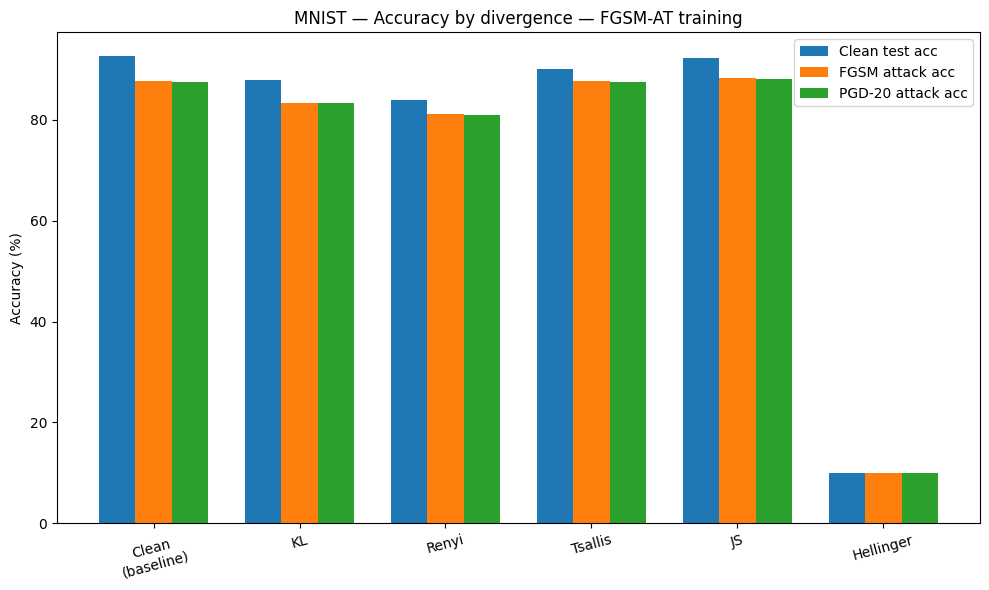

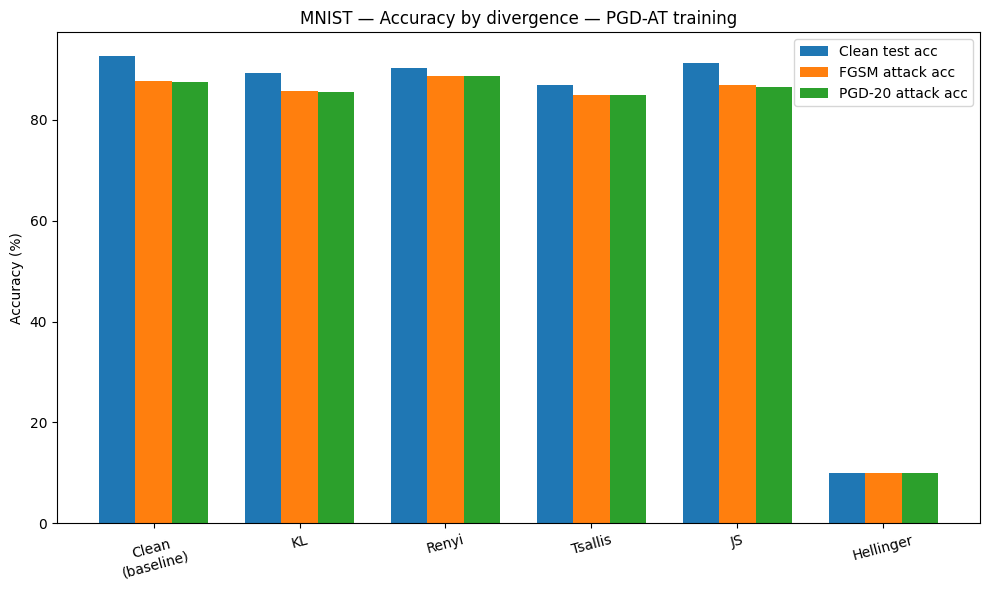

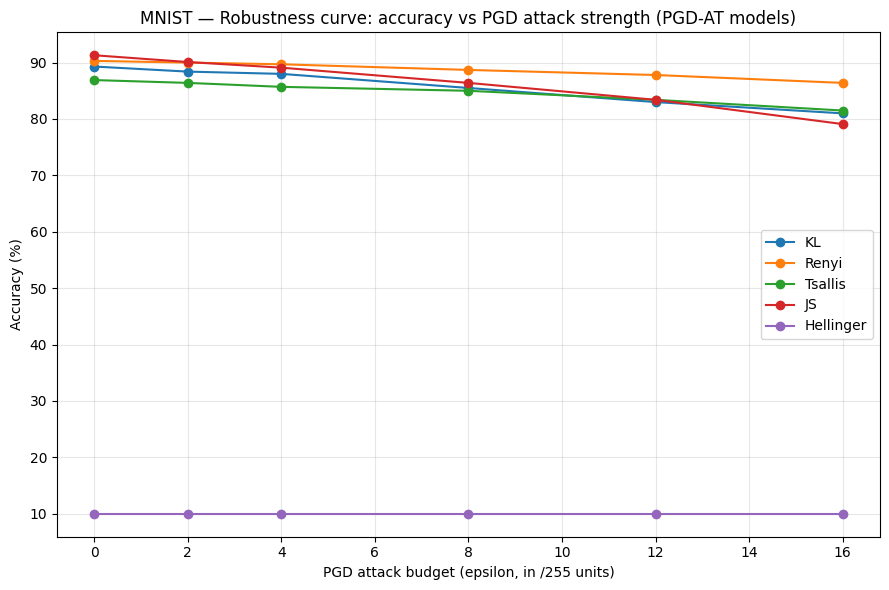

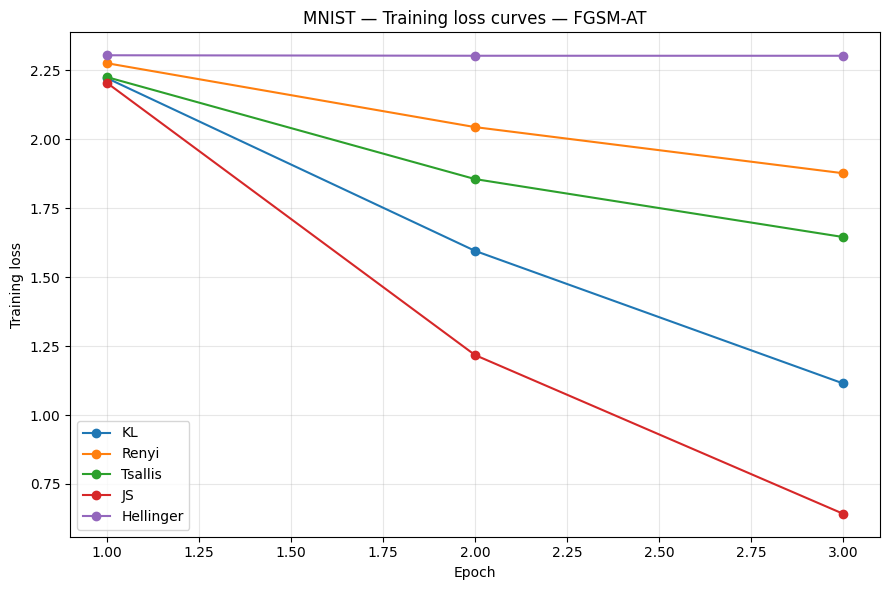

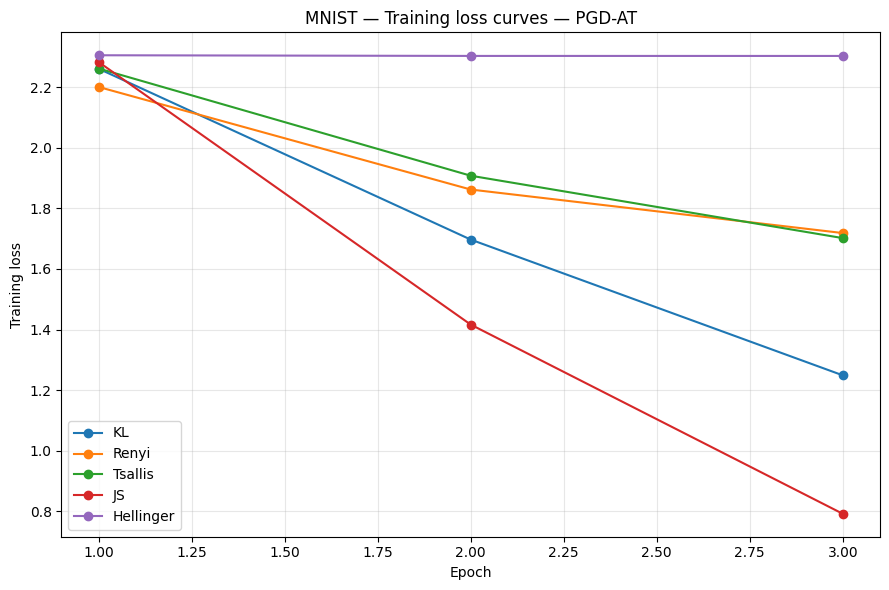

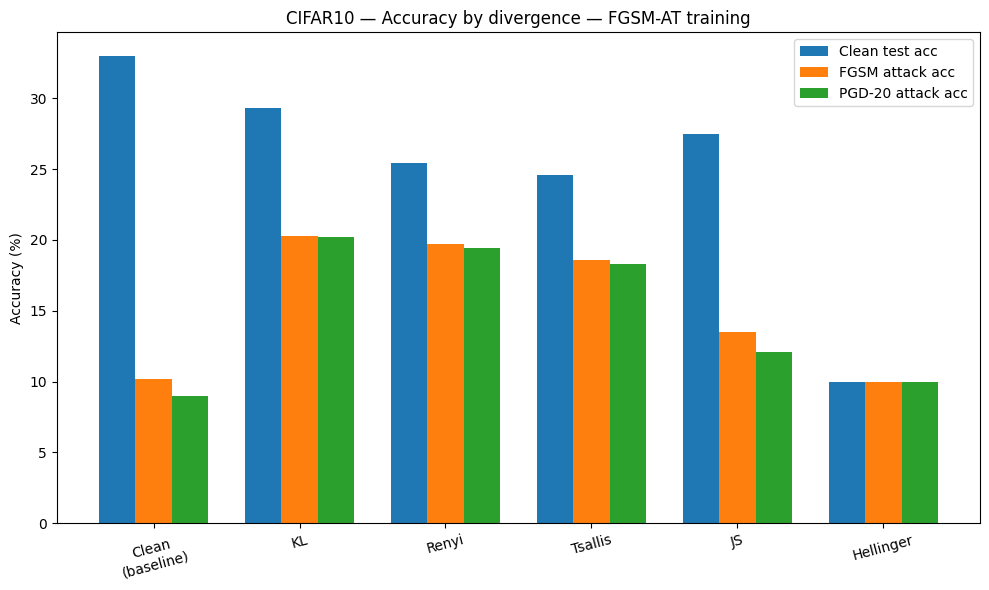

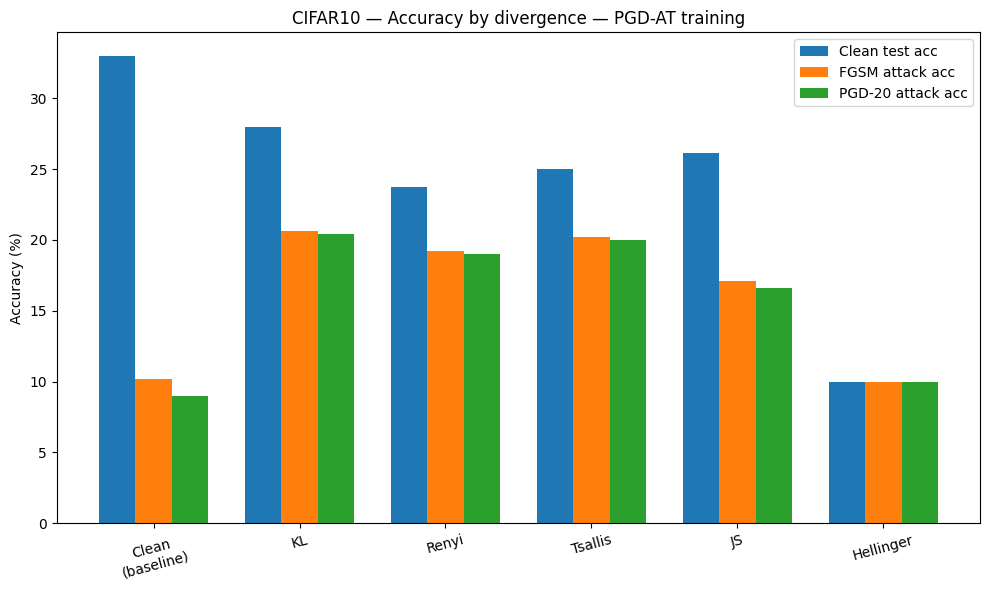

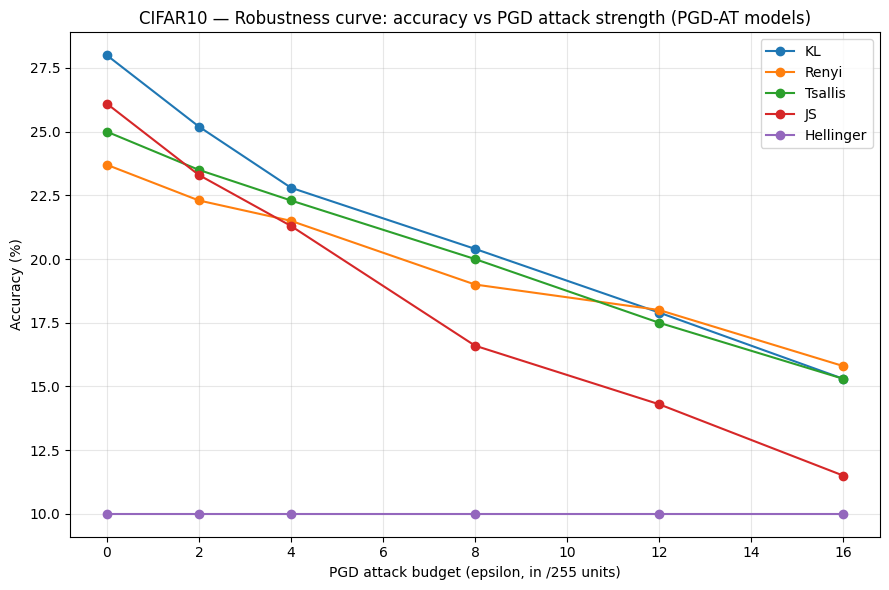

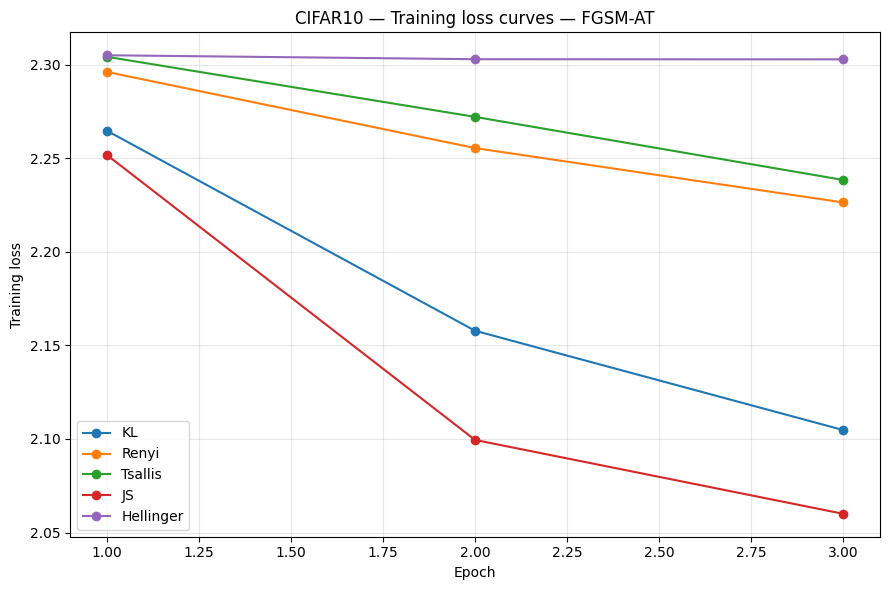

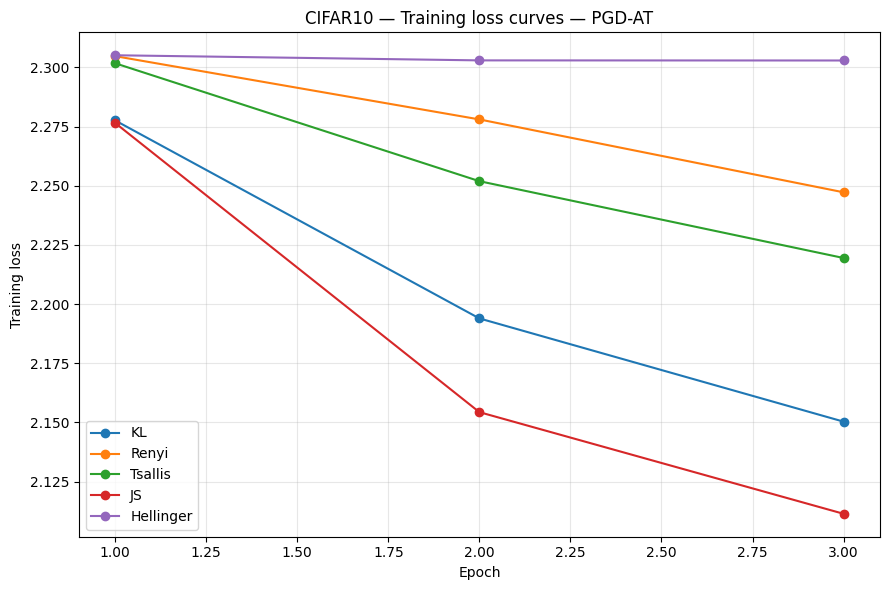

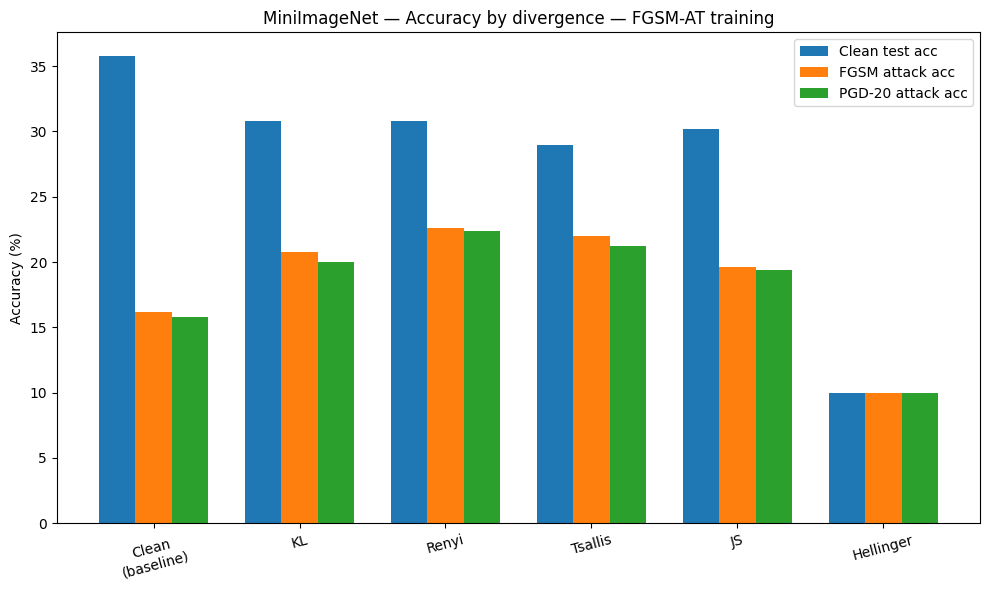

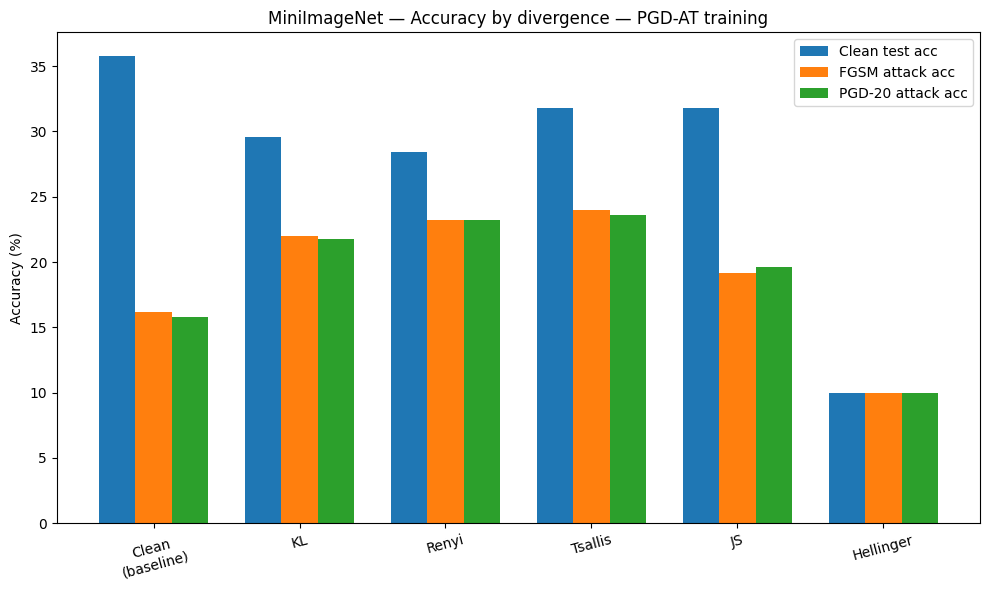

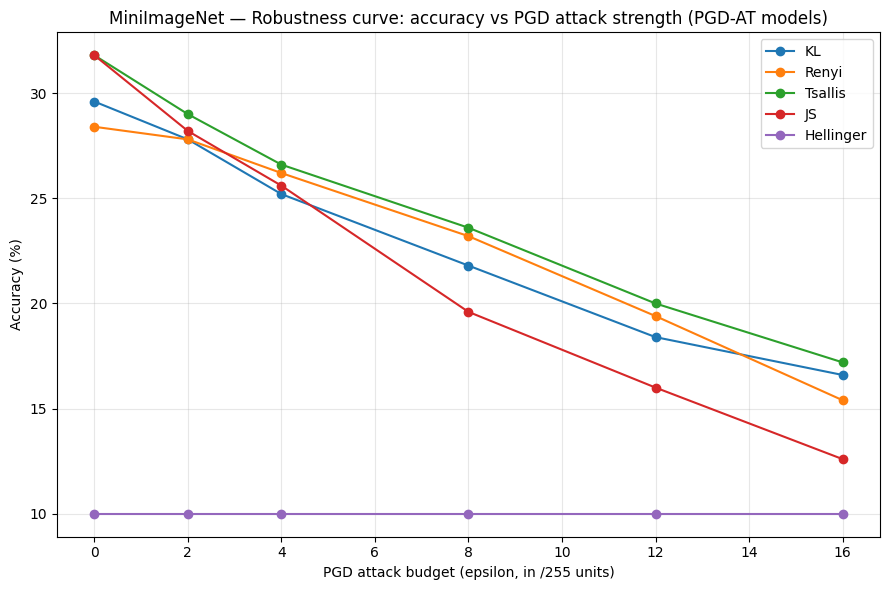

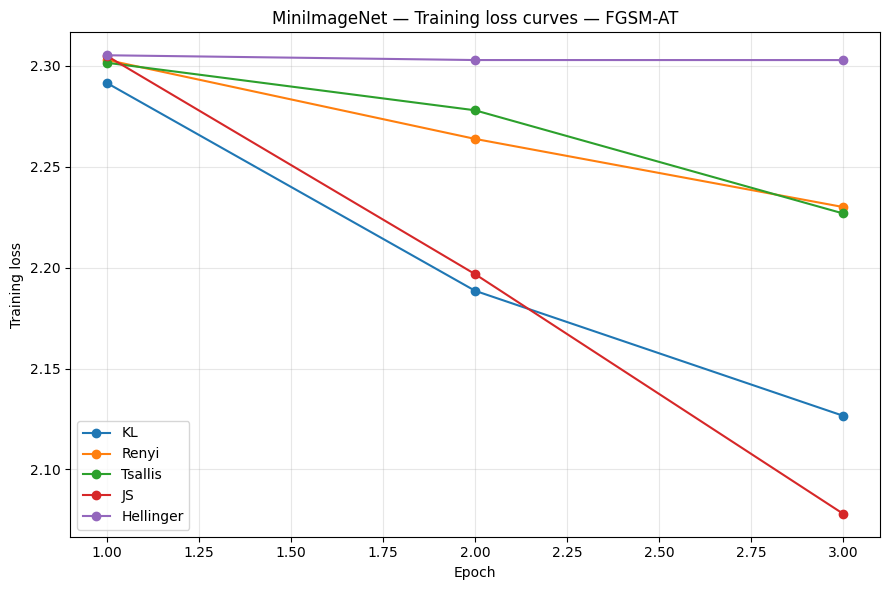

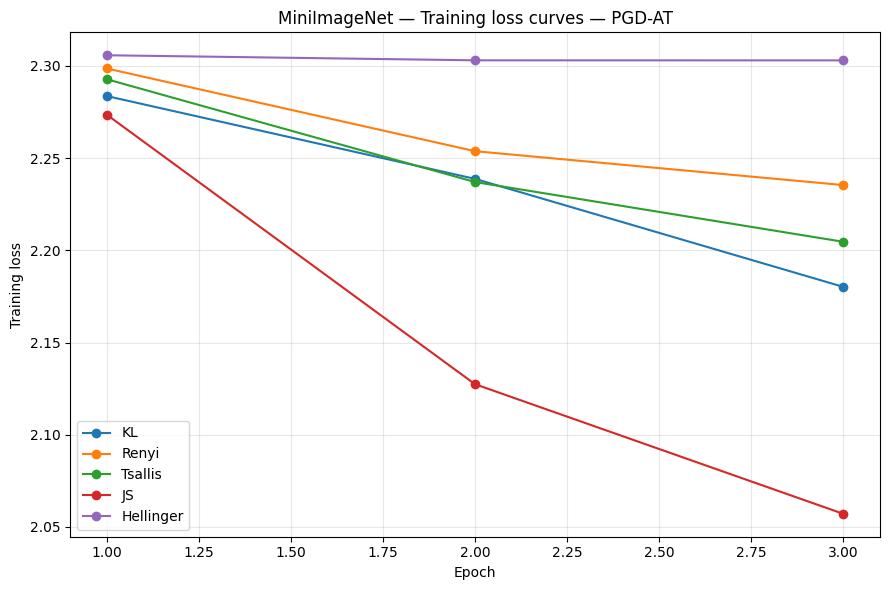

In [ ]:

def plot_grouped_bars(ds_name, mode, filename=None):
    base = all_clean_baseline[ds_name]
    res = all_results[ds_name][mode]
    names = ["Clean\n(baseline)"] + list(res.keys())
    clean_accs = [base["clean"]] + [res[n]["clean"] for n in res]
    fgsm_accs  = [base["fgsm"]]  + [res[n]["fgsm"]  for n in res]
    pgd_accs   = [base["pgd"]]   + [res[n]["pgd"]   for n in res]

    x = np.arange(len(names))
    width = 0.25
    plt.figure(figsize=(10, 6))
    plt.bar(x - width, clean_accs, width, label="Clean test acc")
    plt.bar(x,          fgsm_accs, width, label="FGSM attack acc")
    plt.bar(x + width,  pgd_accs,  width, label="PGD-20 attack acc")
    plt.xticks(x, names, rotation=15)
    plt.ylabel("Accuracy (%)")
    plt.title(f"{ds_name} — Accuracy by divergence — {mode.upper()}-AT training")
    plt.legend()
    plt.tight_layout()
    if filename:
        plt.savefig(filename, dpi=150)
    plt.show()


def plot_eps_sweep(ds_name, filename=None):
    plt.figure(figsize=(9, 6))
    for name, accs in all_eps_sweep[ds_name].items():
        plt.plot([e * 255 for e in EPS_SWEEP], accs, marker="o", label=name)
    plt.xlabel("PGD attack budget (epsilon, in /255 units)")
    plt.ylabel("Accuracy (%)")
    plt.title(f"{ds_name} — Robustness curve: accuracy vs PGD attack strength (PGD-AT models)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    if filename:
        plt.savefig(filename, dpi=150)
    plt.show()


def plot_loss_curves(ds_name, mode, filename=None):
    plt.figure(figsize=(9, 6))
    for name, hist in all_loss_hist[ds_name][mode].items():
        plt.plot(range(1, len(hist) + 1), hist, marker="o", label=name)
    plt.xlabel("Epoch")
    plt.ylabel("Training loss")
    plt.title(f"{ds_name} — Training loss curves — {mode.upper()}-AT")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    if filename:
        plt.savefig(filename, dpi=150)
    plt.show()


for ds_name in DATASET_LOADERS.keys():
    plot_grouped_bars(ds_name, "fgsm", OUT_DIR / f"{ds_name}_fgsm_at_accuracy.png")
    plot_grouped_bars(ds_name, "pgd",  OUT_DIR / f"{ds_name}_pgd_at_accuracy.png")
    plot_eps_sweep(ds_name, OUT_DIR / f"{ds_name}_eps_sweep.png")
    plot_loss_curves(ds_name, "fgsm", OUT_DIR / f"{ds_name}_fgsm_loss_curves.png")
    plot_loss_curves(ds_name, "pgd",  OUT_DIR / f"{ds_name}_pgd_loss_curves.png")


## 12. Gradient-Masking / Robustness-Overestimation Check

Directly borrowing the base paper's diagnostic: if a model's **white-box PGD-20**
accuracy is much higher than its **black-box Square Attack** accuracy, that gap is a
signature of **gradient masking** — the model looks robust to gradient-based attacks
but isn't genuinely robust. The paper flags a training instance as "unstable" when
this gap is **≥ 8 percentage points** (`GRADIENT_MASKING_GAP_THRESHOLD`); we apply the
same threshold here across every PGD-AT model from Section 9.


In [ ]:

if RUN_AUTOATTACK:
    gap_rows = []
    for ds_name in DATASET_LOADERS.keys():
        for div_name, res in all_results[ds_name]["pgd"].items():
            gap = res["pgd"] - res["square"]
            gap_rows.append({
                "Dataset": ds_name, "Divergence": div_name,
                "PGD-20 Acc (%)": res["pgd"], "Square Acc (%)": res["square"],
                "Gap (pp)": gap,
                "Flag": "UNSTABLE (possible gradient masking)" if gap >= GRADIENT_MASKING_GAP_THRESHOLD else "regular",
            })
    gap_df = pd.DataFrame(gap_rows).round(2)
    gap_df.to_csv(OUT_DIR / "gradient_masking_check.csv", index=False)
    display(gap_df)

    n_unstable = (gap_df["Flag"] != "regular").sum()
    print(f"\n{n_unstable} / {len(gap_df)} (dataset, divergence) PGD-AT models flagged as possibly unstable "
          f"(gap >= {GRADIENT_MASKING_GAP_THRESHOLD}pp).")

    plt.figure(figsize=(11, 6))
    labels = gap_df["Dataset"] + " / " + gap_df["Divergence"]
    colors = ["tab:red" if f != "regular" else "tab:blue" for f in gap_df["Flag"]]
    plt.bar(labels, gap_df["Gap (pp)"], color=colors)
    plt.axhline(GRADIENT_MASKING_GAP_THRESHOLD, color="black", linestyle="--", label=f"Instability threshold ({GRADIENT_MASKING_GAP_THRESHOLD}pp)")
    plt.ylabel("PGD-20 acc − Square acc (pp)")
    plt.title("Gradient-masking gap by dataset and divergence (PGD-AT models)")
    plt.xticks(rotation=60, ha="right")
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUT_DIR / "gradient_masking_gap.png", dpi=150)
    plt.show()
else:
    print("RUN_AUTOATTACK is False -- Square Attack accuracy wasn't computed, so this check is skipped. "
          "Set RUN_AUTOATTACK = True in Section 2 and re-run Section 9 to enable it.")


## 13. Final Summary

Re-displays every per-dataset table together, and lists everything saved to `./outputs/`.


In [ ]:

for ds_name, df in result_tables.items():
    print(f"\n{'='*20} {ds_name} {'='*20}")
    display(df)

print("\nFiles written to ./outputs/:")
for f in sorted(OUT_DIR.glob("*")):
    print(" -", f.name)



==================== MNIST ====================


,Training,Divergence,Clean Acc (%),FGSM Acc (%),PGD-20 Acc (%),AutoAttack Acc (%),Square Acc (%)
0,Clean (no defense),-,92.7,87.6,87.4,87.5,88.0
1,FGSM-AT,KL,87.8,83.4,83.4,80.0,80.0
2,FGSM-AT,Renyi,83.9,81.1,81.0,73.0,73.5
3,FGSM-AT,Tsallis,90.0,87.6,87.4,84.5,85.0
4,FGSM-AT,JS,92.2,88.2,88.0,87.5,88.5
5,FGSM-AT,Hellinger,10.0,10.0,10.0,8.0,8.0
6,PGD-AT,KL,89.3,85.7,85.5,81.0,81.0
7,PGD-AT,Renyi,90.3,88.7,88.7,85.5,86.5
8,PGD-AT,Tsallis,86.9,85.0,85.0,85.5,86.0
9,PGD-AT,JS,91.3,86.8,86.5,85.5,85.5



==================== CIFAR10 ====================


,Training,Divergence,Clean Acc (%),FGSM Acc (%),PGD-20 Acc (%),AutoAttack Acc (%),Square Acc (%)
0,Clean (no defense),-,33.0,10.2,9.0,5.5,7.5
1,FGSM-AT,KL,29.3,20.3,20.2,19.5,22.5
2,FGSM-AT,Renyi,25.4,19.7,19.4,16.0,18.0
3,FGSM-AT,Tsallis,24.6,18.6,18.3,19.5,19.5
4,FGSM-AT,JS,27.5,13.5,12.1,9.5,11.0
5,FGSM-AT,Hellinger,10.0,10.0,10.0,7.5,7.5
6,PGD-AT,KL,28.0,20.6,20.4,20.5,21.0
7,PGD-AT,Renyi,23.7,19.2,19.0,17.5,18.0
8,PGD-AT,Tsallis,25.0,20.2,20.0,17.5,18.0
9,PGD-AT,JS,26.1,17.1,16.6,18.0,19.0



==================== MiniImageNet ====================


,Training,Divergence,Clean Acc (%),FGSM Acc (%),PGD-20 Acc (%),AutoAttack Acc (%),Square Acc (%)
0,Clean (no defense),-,35.8,16.2,15.8,15.0,20.5
1,FGSM-AT,KL,30.8,20.8,20.0,19.0,20.0
2,FGSM-AT,Renyi,30.8,22.6,22.4,21.0,23.0
3,FGSM-AT,Tsallis,29.0,22.0,21.2,23.0,24.5
4,FGSM-AT,JS,30.2,19.6,19.4,18.5,19.5
5,FGSM-AT,Hellinger,10.0,10.0,10.0,11.0,11.0
6,PGD-AT,KL,29.6,22.0,21.8,23.5,24.0
7,PGD-AT,Renyi,28.4,23.2,23.2,20.5,23.5
8,PGD-AT,Tsallis,31.8,24.0,23.6,23.5,24.5
9,PGD-AT,JS,31.8,19.2,19.6,20.0,22.0



Files written to ./outputs/:
 - CIFAR10_eps_sweep.png
 - CIFAR10_fgsm_at_accuracy.png
 - CIFAR10_fgsm_loss_curves.png
 - CIFAR10_pgd_at_accuracy.png
 - CIFAR10_pgd_loss_curves.png
 - MNIST_eps_sweep.png
 - MNIST_fgsm_at_accuracy.png
 - MNIST_fgsm_loss_curves.png
 - MNIST_pgd_at_accuracy.png
 - MNIST_pgd_loss_curves.png
 - MiniImageNet_eps_sweep.png
 - MiniImageNet_fgsm_at_accuracy.png
 - MiniImageNet_fgsm_loss_curves.png
 - MiniImageNet_pgd_at_accuracy.png
 - MiniImageNet_pgd_loss_curves.png
 - gradient_masking_check.csv
 - gradient_masking_gap.png
 - results_CIFAR10.csv
 - results_MNIST.csv
 - results_MiniImageNet.csv


### What's faithfully reproduced from the base paper, and what isn't

**Reproduced / directly borrowed:**
- The TRADES loss form itself ($\mathcal{CE} + \beta \cdot \mathcal{D}$) and its TPGD/TFGSM inner maximization.
- Multi-attack evaluation table (Clean / PGD / AutoAttack, i.e. APGD-CE + APGD-DLR + FAB + Square) — the paper's Table 1 format, here per-dataset per-divergence.
- The specific **PGD-vs-Square gap** diagnostic and **8-percentage-point threshold** the paper uses to flag "unstable" (gradient-masked) runs (Section 4.1, Tables 1/2/4).
- Testing across datasets of increasing class/visual complexity (paper: CIFAR-10 → CIFAR-100 → Tiny-ImageNet-200; here: MNIST → CIFAR-10 → Mini-ImageNet), since the paper explicitly finds complexity correlates with instability (Appendix C).

**Not implemented here (a genuinely separate, training-trajectory-level project, not just an eval question):**
- **FOSC** (First-Order Stationary Condition) and **SGCS** (Step-wise Gradient Cosine Similarity) tracked *during* training — these need per-batch/per-epoch instrumentation of the attack's own convergence, not just final accuracy.
- **Loss-landscape surface plots** (Figure 1 of the paper) — requires sweeping the model along two directions in input space and plotting loss as a 3D surface.
- **Batch-level gradient-norm tracking** (W_Grad_Norm, CE_Norm, KL_Norm, grad_cosine_similarity — Appendix G) — needs gradient hooks recorded every training step.
- **"Self-healing" detection and Algorithm 1's Gaussian-noise fix** — an active, epoch-by-epoch intervention during training, not a post-hoc analysis.
- **Batch-size sweep** and **learning-rate-schedule sensitivity** (Table 2, Appendix D) — easy to add but omitted here to keep runtime bounded; say the word if you want them added as a follow-up section.
- **Re-running the $\alpha$-sweep / $\beta$-sweep live** — deliberately removed in this version. Their best values (Rényi $\alpha{=}3.0$, Tsallis $\alpha{=}2.0$, $\beta{=}10.0$) are taken from the original notebook's own executed sweep outputs and hard-coded in Section 2 instead, so every model trained below already uses the tuned hyperparameters.
- The paper always uses **ResNet-18** at full CIFAR/Tiny-ImageNet scale, 100–200 epochs; here it's a small custom CNN on data subsets for Colab feasibility, so **absolute numbers won't match the paper's** — only the *relative* patterns (divergence choice, $\beta$ effect, gradient-masking gap) are meant to transfer.

If you want the FOSC/SGCS + loss-landscape + Algorithm-1 pieces added, that's a solid follow-up notebook — it reuses everything built here (attacks, divergences, training loop) but adds per-step instrumentation and a live-intervention training loop.
